# Evaluasi Latensi dan Throughput Pipeline Lambda

In [ ]:
# ============================================================
# EKSPERIMEN: Evaluasi Latensi & Throughput Pipeline Lambda
# (a) Stream  : Simulasi Kafka + Flink  → Latensi & Throughput
# (b) Batch   : Apache Spark (nyata)    → Speedup Ratio
# Platform    : Google Colab Gratis
# ============================================================

# Install PySpark (sungguhan, bukan simulasi)
!pip install pyspark --quiet
!pip install psutil --quiet

import pandas as pd
import numpy as np
import time
import threading
import queue
import psutil
import os
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque
from datetime import datetime, timedelta
from concurrent.futures import ThreadPoolExecutor
warnings.filterwarnings('ignore')

# PySpark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *

print("Semua library berhasil dimuat.")
print(f"CPU cores tersedia : {os.cpu_count()}")
print(f"RAM tersedia       : {psutil.virtual_memory().available / 1e9:.1f} GB")

Semua library berhasil dimuat.
CPU cores tersedia : 2
RAM tersedia       : 12.2 GB


In [ ]:
# ============================================================
# CELL 2: LOAD DATA & KONFIGURASI GLOBAL
# ============================================================

FILE_PATH = '5v_cleandf_relevant.csv'   # sesuaikan path

print("Membaca dataset...")
df_raw = pd.read_csv(FILE_PATH)
print(f"Dataset shape : {df_raw.shape}")

# Kolom yang diproses pipeline
PIPELINE_COLS = [
    'dep_name', 'esi', 'age', 'gender', 'arrivalmode',
    'arrivalhour_bin', 'arrivalday', 'arrivalmonth',
    'previousdispo', 'albumin_last', 'aniongap_last',
    'bilirubintotal_last', 'disposition'
]

df = df_raw[PIPELINE_COLS].copy()

# ── Konfigurasi eksperimen ──────────────────────────────────
CFG = {
    # Stream (Kafka+Flink simulasi)
    'NORMAL_RATE_PER_SEC' : 50,     # pasien/detik saat normal
    'PEAK_MULTIPLIER'     : 4.5,    # rasio beban jam puncak (4.5×)
    'STREAM_DURATION_SEC' : 30,     # durasi simulasi per skenario (detik)
    'KAFKA_PARTITIONS'    : 3,      # partisi Kafka (1 per dep: A,B,C)
    'FLINK_PARALLELISM'   : 3,      # parallelisme Flink operator
    'FLINK_WINDOW_SEC'    : 5,      # tumbling window Flink (detik)

    # Batch (Spark)
    'BATCH_SAMPLE_SIZES'  : [50_000, 100_000, 200_000, 400_000],
    'SINGLE_NODE_THREADS' : 1,
    'SPARK_THREADS'       : 4,      # Colab gratis: max 2-4 core
}

# Konversi data ke list of dict untuk replay (lebih cepat dari iterrow)
records = df.fillna(-1).to_dict(orient='records')
print(f"Total records siap di-replay : {len(records):,}")
print(f"\nKonfigurasi eksperimen:")
for k, v in CFG.items():
    print(f"  {k:<28} : {v}")

Membaca dataset...
Dataset shape : (560486, 23)
Total records siap di-replay : 560,486

Konfigurasi eksperimen:
  NORMAL_RATE_PER_SEC          : 50
  PEAK_MULTIPLIER              : 4.5
  STREAM_DURATION_SEC          : 30
  KAFKA_PARTITIONS             : 3
  FLINK_PARALLELISM            : 3
  FLINK_WINDOW_SEC             : 5
  BATCH_SAMPLE_SIZES           : [50000, 100000, 200000, 400000]
  SINGLE_NODE_THREADS          : 1
  SPARK_THREADS                : 4


In [ ]:
# ============================================================
# CELL 3: KOMPONEN SIMULASI KAFKA + FLINK
# ============================================================
# Arsitektur simulasi:
#
#  [Producer Thread]                    mereplikasi Kafka Producer
#       │  records → topic queue
#       ▼
#  [Kafka Broker Sim]                   queue per partisi (3 partisi)
#       │  round-robin partitioning
#       ▼
#  [Flink Consumer Threads × 3]         mereplikasi Flink parallel operator
#       │  tumbling window aggregation
#       ▼
#  [Sink / Metrics Collector]           catat latensi end-to-end

class KafkaBrokerSimulator:
    """
    Simulasi Kafka broker dengan N partisi.
    Setiap partisi = satu queue FIFO (bounded).
    Catat timestamp 'enqueue' untuk hitung latensi.
    """
    def __init__(self, n_partitions=3, max_queue_size=10_000):
        self.n_partitions  = n_partitions
        self.partitions    = [queue.Queue(maxsize=max_queue_size)
                              for _ in range(n_partitions)]
        self.total_produced = 0
        self.dropped        = 0
        self._lock          = threading.Lock()

    def produce(self, record, partition_key=None):
        """Round-robin atau key-based partitioning."""
        if partition_key is not None:
            p_idx = hash(partition_key) % self.n_partitions
        else:
            with self._lock:
                p_idx = self.total_produced % self.n_partitions

        msg = {
            'record'       : record,
            'enqueue_time' : time.perf_counter(),
            'partition'    : p_idx
        }
        try:
            self.partitions[p_idx].put_nowait(msg)
            with self._lock:
                self.total_produced += 1
            return True
        except queue.Full:
            with self._lock:
                self.dropped += 1
            return False

    def consume(self, partition_idx, timeout=0.01):
        try:
            return self.partitions[partition_idx].get(timeout=timeout)
        except queue.Empty:
            return None

    def total_pending(self):
        return sum(q.qsize() for q in self.partitions)


class FlinkOperatorSimulator:
    """
    Simulasi satu Flink parallel operator (task slot).
    Tugasnya:
      1. Consume dari partisi Kafka yang ditugaskan
      2. Parsing + feature extraction (latency processing)
      3. Tumbling window aggregation per dep
      4. Catat latensi end-to-end (enqueue → sink)
    """
    def __init__(self, operator_id, kafka_broker, partition_idx,
                 window_sec, metrics_collector):
        self.op_id       = operator_id
        self.broker      = kafka_broker
        self.part_idx    = partition_idx
        self.window_sec  = window_sec
        self.metrics     = metrics_collector
        self.running     = False
        self._window_buf = []
        self._win_start  = time.perf_counter()

    def _process_record(self, msg):
        """Simulasi Flink map/filter/aggregate operator."""
        rec = msg['record']

        # -- Simulasi feature extraction (operasi ringan, realistis) --
        esi_val  = rec.get('esi', -1)
        dep_val  = rec.get('dep_name', 'X')
        age_val  = rec.get('age', 0)

        # Klasifikasi ESI group (logika M2)
        if esi_val in [1, 2]:
            priority = 'critical'
        elif esi_val == 3:
            priority = 'moderate'
        else:
            priority = 'minor'

        # Simulasi enrichment latency (~0.05-0.2 ms per record)
        time.sleep(np.random.uniform(0.00005, 0.0002))

        return {
            'dep'      : dep_val,
            'priority' : priority,
            'esi'      : esi_val,
            'age'      : age_val,
            'ts'       : msg['enqueue_time']
        }

    def _flush_window(self, window_records):
        """Tumbling window: hitung agregat per dep."""
        if not window_records:
            return
        deps = {}
        for r in window_records:
            d = r['dep']
            if d not in deps:
                deps[d] = {'count': 0, 'critical': 0}
            deps[d]['count'] += 1
            if r['priority'] == 'critical':
                deps[d]['critical'] += 1
        # Sink output (discard, hanya untuk benchmark)
        return deps

    def run(self, stop_event):
        self.running   = True
        self._win_start = time.perf_counter()

        while not stop_event.is_set():
            msg = self.broker.consume(self.part_idx, timeout=0.005)
            if msg is None:
                continue

            processed       = self._process_record(msg)
            dequeue_time    = time.perf_counter()
            latency_ms      = (dequeue_time - msg['enqueue_time']) * 1000

            self.metrics['latencies'].append(latency_ms)
            self.metrics['processed'] += 1
            self._window_buf.append(processed)

            # Flush tumbling window
            now = time.perf_counter()
            if now - self._win_start >= self.window_sec:
                self._flush_window(self._window_buf)
                self._window_buf = []
                self._win_start  = now

        self.running = False


print("Komponen Kafka + Flink simulator siap.")

Komponen Kafka + Flink simulator siap.


In [ ]:
# ============================================================
# CELL 4: FUNGSI PENGUKURAN STREAM PIPELINE
# ============================================================

def run_stream_experiment(rate_per_sec, duration_sec, label,
                          n_partitions=3, n_flink_ops=3,
                          window_sec=5):
    """
    Jalankan simulasi pipeline stream selama `duration_sec` detik
    pada kecepatan `rate_per_sec` records/detik.

    Returns
    -------
    dict: metrik latensi & throughput
    """
    print(f"\n  ▶ [{label}] rate={rate_per_sec} rec/s | "
          f"durasi={duration_sec}s ...")

    # Shared metrics (thread-safe via list append → GIL cukup untuk append)
    metrics = {
        'latencies' : [],
        'processed' : 0,
    }

    broker      = KafkaBrokerSimulator(n_partitions=n_partitions)
    stop_event  = threading.Event()

    # Buat Flink operators
    flink_ops = [
        FlinkOperatorSimulator(
            operator_id       = i,
            kafka_broker      = broker,
            partition_idx     = i % n_partitions,
            window_sec        = window_sec,
            metrics_collector = metrics
        )
        for i in range(n_flink_ops)
    ]

    # Jalankan Flink consumers di thread terpisah
    flink_threads = []
    for op in flink_ops:
        t = threading.Thread(target=op.run, args=(stop_event,), daemon=True)
        t.start()
        flink_threads.append(t)

    # Producer: replay records dari dataset pada kecepatan target
    interval    = 1.0 / rate_per_sec   # detik antar record
    start_time  = time.perf_counter()
    total_sent  = 0
    rec_idx     = 0
    n_records   = len(records)

    producer_latencies = []   # waktu antrian di sisi producer

    while time.perf_counter() - start_time < duration_sec:
        t0  = time.perf_counter()
        rec = records[rec_idx % n_records]
        rec_idx += 1

        # Partisi berdasarkan dep_name
        broker.produce(rec, partition_key=rec.get('dep_name'))
        total_sent += 1

        # Busy-wait presisi tinggi
        elapsed = time.perf_counter() - t0
        sleep_t = interval - elapsed
        if sleep_t > 0:
            time.sleep(sleep_t)

    actual_duration = time.perf_counter() - start_time

    # Beri waktu Flink menyelesaikan sisa queue (max 5 detik)
    drain_start = time.perf_counter()
    while broker.total_pending() > 0 and \
          time.perf_counter() - drain_start < 5:
        time.sleep(0.05)

    stop_event.set()
    for t in flink_threads:
        t.join(timeout=3)

    # ── Hitung metrik ──────────────────────────────────────────
    lats    = np.array(metrics['latencies'])
    n_proc  = metrics['processed']

    if len(lats) == 0:
        lats = np.array([0.0])

    result = {
        'label'             : label,
        'rate_per_sec'      : rate_per_sec,
        'duration_sec'      : actual_duration,
        'total_sent'        : total_sent,
        'total_processed'   : n_proc,
        'dropped'           : broker.dropped,
        'throughput_actual' : n_proc / actual_duration,
        'latency_mean_ms'   : float(np.mean(lats)),
        'latency_p50_ms'    : float(np.percentile(lats, 50)),
        'latency_p95_ms'    : float(np.percentile(lats, 95)),
        'latency_p99_ms'    : float(np.percentile(lats, 99)),
        'latency_max_ms'    : float(np.max(lats)),
        'drop_rate_pct'     : broker.dropped / max(total_sent, 1) * 100,
    }

    print(f"    Sent={total_sent:,} | Processed={n_proc:,} | "
          f"Dropped={broker.dropped:,} ({result['drop_rate_pct']:.2f}%)")
    print(f"    Throughput={result['throughput_actual']:.1f} rec/s | "
          f"Lat p50={result['latency_p50_ms']:.2f}ms | "
          f"p95={result['latency_p95_ms']:.2f}ms | "
          f"p99={result['latency_p99_ms']:.2f}ms")

    return result, lats


print("Fungsi pengukuran stream siap.")

Fungsi pengukuran stream siap.


In [ ]:
# ============================================================
# CELL 5: JALANKAN EKSPERIMEN STREAM — NORMAL vs PEAK LOAD
# ============================================================

normal_rate = CFG['NORMAL_RATE_PER_SEC']
peak_rate   = int(normal_rate * CFG['PEAK_MULTIPLIER'])
dur         = CFG['STREAM_DURATION_SEC']

print("="*60)
print("  EKSPERIMEN (a): STREAM PIPELINE — Kafka + Flink Sim")
print(f"  Normal rate : {normal_rate} rec/s")
print(f"  Peak rate   : {peak_rate} rec/s (×{CFG['PEAK_MULTIPLIER']})")
print(f"  Durasi/run  : {dur} detik")
print("="*60)

# --- Run Normal Load ---
result_normal, lats_normal = run_stream_experiment(
    rate_per_sec = normal_rate,
    duration_sec = dur,
    label        = f'Normal ({normal_rate} rec/s)',
    n_partitions = CFG['KAFKA_PARTITIONS'],
    n_flink_ops  = CFG['FLINK_PARALLELISM'],
    window_sec   = CFG['FLINK_WINDOW_SEC']
)

# Jeda sebentar agar sistem bersih
time.sleep(2)

# --- Run Peak Load ---
result_peak, lats_peak = run_stream_experiment(
    rate_per_sec = peak_rate,
    duration_sec = dur,
    label        = f'Peak ({peak_rate} rec/s, ×{CFG["PEAK_MULTIPLIER"]})',
    n_partitions = CFG['KAFKA_PARTITIONS'],
    n_flink_ops  = CFG['FLINK_PARALLELISM'],
    window_sec   = CFG['FLINK_WINDOW_SEC']
)

stream_results = [result_normal, result_peak]

print("\n" + "="*60)
print("  RINGKASAN STREAM RESULTS")
print("="*60)
df_stream = pd.DataFrame(stream_results).set_index('label')
print(df_stream[[
    'rate_per_sec','total_sent','total_processed',
    'throughput_actual','latency_p50_ms',
    'latency_p95_ms','latency_p99_ms','drop_rate_pct'
]].round(2).to_string())

  EKSPERIMEN (a): STREAM PIPELINE — Kafka + Flink Sim
  Normal rate : 50 rec/s
  Peak rate   : 225 rec/s (×4.5)
  Durasi/run  : 30 detik

  ▶ [Normal (50 rec/s)] rate=50 rec/s | durasi=30s ...
    Sent=1,491 | Processed=1,491 | Dropped=0 (0.00%)
    Throughput=49.7 rec/s | Lat p50=0.38ms | p95=0.53ms | p99=0.85ms

  ▶ [Peak (225 rec/s, ×4.5)] rate=225 rec/s | durasi=30s ...
    Sent=6,568 | Processed=6,568 | Dropped=0 (0.00%)
    Throughput=218.9 rec/s | Lat p50=0.36ms | p95=0.50ms | p99=0.75ms

  RINGKASAN STREAM RESULTS
                        rate_per_sec  total_sent  total_processed  throughput_actual  latency_p50_ms  latency_p95_ms  latency_p99_ms  drop_rate_pct
label                                                                                                                                              
Normal (50 rec/s)                 50        1491             1491              49.67            0.38            0.53            0.85            0.0
Peak (225 rec/s, ×4.5)      

In [ ]:
# ============================================================
# CELL 6: EKSPERIMEN (b): BATCH — PySpark Speedup Ratio
# Single-node (1 thread) vs Spark (4 threads)
# ============================================================

def create_spark_session(n_threads, session_name):
    """Buat SparkSession dengan jumlah thread tertentu."""
    return (SparkSession.builder
            .master(f'local[{n_threads}]')
            .appName(session_name)
            .config('spark.driver.memory', '2g')
            .config('spark.sql.shuffle.partitions', str(n_threads * 2))
            .config('spark.ui.showConsoleProgress', 'false')
            .getOrCreate())


def run_batch_pipeline_spark(spark, df_pandas, label):
    """
    Jalankan pipeline batch IGD menggunakan Spark:
    1. Ingest DataFrame
    2. Filter & cleaning
    3. Agregasi occupancy per jam per dep
    4. Feature engineering untuk model prediksi
    5. Group statistics
    Ukur wall-clock time dari start ke end.
    """
    t_start = time.perf_counter()

    # -- Konversi ke Spark DF --
    schema = StructType([
        StructField('dep_name',            StringType(),  True),
        StructField('esi',                 FloatType(),   True),
        StructField('age',                 FloatType(),   True),
        StructField('gender',              StringType(),  True),
        StructField('arrivalmode',         StringType(),  True),
        StructField('arrivalhour_bin',     StringType(),  True),
        StructField('arrivalday',          StringType(),  True),
        StructField('arrivalmonth',        StringType(),  True),
        StructField('previousdispo',       StringType(),  True),
        StructField('albumin_last',        FloatType(),   True),
        StructField('aniongap_last',       FloatType(),   True),
        StructField('bilirubintotal_last', FloatType(),   True),
        StructField('disposition',         StringType(),  True),
    ])

    sdf = spark.createDataFrame(df_pandas, schema=schema)

    # -- Stage 1: Filter invalid ESI --
    sdf = sdf.filter(F.col('esi').isNotNull() &
                     F.col('esi').between(1, 5))

    # -- Stage 2: ESI priority labeling --
    sdf = sdf.withColumn('priority',
        F.when(F.col('esi') <= 2, 'critical')
         .when(F.col('esi') == 3, 'moderate')
         .otherwise('minor')
    )

    # -- Stage 3: Admit flag --
    sdf = sdf.withColumn('admit_flag',
        F.when(F.col('disposition') == 'Admit', 1).otherwise(0)
    )

    # -- Stage 4: Agregasi per dep + jam --
    agg_hourly = (sdf.groupBy('dep_name', 'arrivalhour_bin', 'arrivalday')
                     .agg(
                         F.count('*').alias('n_arrivals'),
                         F.sum('admit_flag').alias('n_admit'),
                         F.avg('esi').alias('avg_esi'),
                         F.avg('age').alias('avg_age'),
                         F.avg('albumin_last').alias('avg_albumin'),
                         F.avg('aniongap_last').alias('avg_aniongap'),
                     ))

    # -- Stage 5: Admit rate & occupancy score --
    agg_hourly = agg_hourly.withColumn(
        'admit_rate',
        F.col('n_admit') / F.col('n_arrivals')
    )

    # -- Stage 6: Collect (trigger actual execution) --
    result = agg_hourly.collect()

    t_end     = time.perf_counter()
    wall_time = t_end - t_start

    n_rows_in   = df_pandas.shape[0]
    n_rows_out  = len(result)
    throughput  = n_rows_in / wall_time

    print(f"    [{label}] rows={n_rows_in:,} | "
          f"time={wall_time:.3f}s | "
          f"throughput={throughput:,.0f} rows/s | "
          f"agg_rows={n_rows_out}")

    return {
        'label'       : label,
        'n_rows'      : n_rows_in,
        'wall_time_s' : wall_time,
        'throughput'  : throughput,
        'n_output'    : n_rows_out,
    }


def run_batch_pipeline_singlenode(df_pandas, label):
    """
    Pipeline batch identik tapi menggunakan Pandas murni
    (single-node baseline untuk hitung speedup ratio).
    """
    t_start = time.perf_counter()

    dp = df_pandas.copy()

    # Stage 1: Filter
    dp = dp[dp['esi'].notna() & dp['esi'].between(1, 5)]

    # Stage 2: Priority labeling
    dp['priority'] = pd.cut(dp['esi'],
                            bins=[0,2,3,5],
                            labels=['critical','moderate','minor'])

    # Stage 3: Admit flag
    dp['admit_flag'] = (dp['disposition'] == 'Admit').astype(int)

    # Stage 4: Agregasi
    agg = dp.groupby(['dep_name','arrivalhour_bin','arrivalday']).agg(
        n_arrivals   = ('esi',         'count'),
        n_admit      = ('admit_flag',  'sum'),
        avg_esi      = ('esi',         'mean'),
        avg_age      = ('age',         'mean'),
        avg_albumin  = ('albumin_last','mean'),
        avg_aniongap = ('aniongap_last','mean'),
    ).reset_index()

    # Stage 5: Admit rate
    agg['admit_rate'] = agg['n_admit'] / agg['n_arrivals']

    t_end     = time.perf_counter()
    wall_time = t_end - t_start
    throughput = df_pandas.shape[0] / wall_time

    print(f"    [{label}] rows={df_pandas.shape[0]:,} | "
          f"time={wall_time:.3f}s | "
          f"throughput={throughput:,.0f} rows/s")

    return {
        'label'       : label,
        'n_rows'      : df_pandas.shape[0],
        'wall_time_s' : wall_time,
        'throughput'  : throughput,
        'n_output'    : len(agg),
    }


print("Fungsi batch pipeline siap.")

Fungsi batch pipeline siap.


In [ ]:
# ============================================================
# CELL 7: JALANKAN EKSPERIMEN BATCH — Single-node vs Spark
# ============================================================

print("="*60)
print("  EKSPERIMEN (b): BATCH — Single-node vs Apache Spark")
print("="*60)

batch_results = []
sample_sizes  = CFG['BATCH_SAMPLE_SIZES']

# Inisialisasi dua SparkSession (satu per konfigurasi)
print("\nMembuat SparkSession...")
spark_single = create_spark_session(
    CFG['SINGLE_NODE_THREADS'], 'Lambda_SingleNode')
spark_multi  = create_spark_session(
    CFG['SPARK_THREADS'], 'Lambda_Spark')

for n in sample_sizes:
    print(f"\n  ── Sample size: {n:,} rows ──")

    # Ambil sample (deterministik)
    df_sample = df.sample(n=min(n, len(df)),
                          random_state=42).reset_index(drop=True)

    # Warmup kecil agar JVM Spark sudah panas
    if n == sample_sizes[0]:
        _ = run_batch_pipeline_spark(
            spark_multi,
            df_sample.head(1000),
            'warmup'
        )

    # Single-node (Pandas)
    r_single = run_batch_pipeline_singlenode(
        df_sample,
        f'SingleNode n={n:,}'
    )

    # Spark multi-thread
    r_spark  = run_batch_pipeline_spark(
        spark_multi,
        df_sample,
        f'Spark({CFG["SPARK_THREADS"]}t) n={n:,}'
    )

    speedup = r_single['wall_time_s'] / r_spark['wall_time_s']

    batch_results.append({
        'n_rows'              : n,
        'single_time_s'       : round(r_single['wall_time_s'], 4),
        'spark_time_s'        : round(r_spark['wall_time_s'], 4),
        'single_throughput'   : round(r_single['throughput'], 0),
        'spark_throughput'    : round(r_spark['throughput'], 0),
        'speedup_ratio'       : round(speedup, 2),
    })

    print(f"    → Speedup ratio: {speedup:.2f}×")

# Stop sessions
spark_single.stop()
spark_multi.stop()

df_batch = pd.DataFrame(batch_results).set_index('n_rows')
print("\n" + "="*60)
print("  HASIL BATCH EKSPERIMEN")
print("="*60)
print(df_batch.to_string())

  EKSPERIMEN (b): BATCH — Single-node vs Apache Spark

Membuat SparkSession...

  ── Sample size: 50,000 rows ──
    [warmup] rows=1,000 | time=9.348s | throughput=107 rows/s | agg_rows=119
    [SingleNode n=50,000] rows=50,000 | time=0.091s | throughput=547,285 rows/s
    [Spark(4t) n=50,000] rows=50,000 | time=4.629s | throughput=10,801 rows/s | agg_rows=126
    → Speedup ratio: 0.02×

  ── Sample size: 100,000 rows ──
    [SingleNode n=100,000] rows=100,000 | time=0.086s | throughput=1,166,222 rows/s
    [Spark(4t) n=100,000] rows=100,000 | time=3.087s | throughput=32,396 rows/s | agg_rows=126
    → Speedup ratio: 0.03×

  ── Sample size: 200,000 rows ──
    [SingleNode n=200,000] rows=200,000 | time=0.128s | throughput=1,565,445 rows/s
    [Spark(4t) n=200,000] rows=200,000 | time=4.463s | throughput=44,815 rows/s | agg_rows=126
    → Speedup ratio: 0.03×

  ── Sample size: 400,000 rows ──
    [SingleNode n=400,000] rows=400,000 | time=0.363s | throughput=1,101,519 rows/s
    [Spar

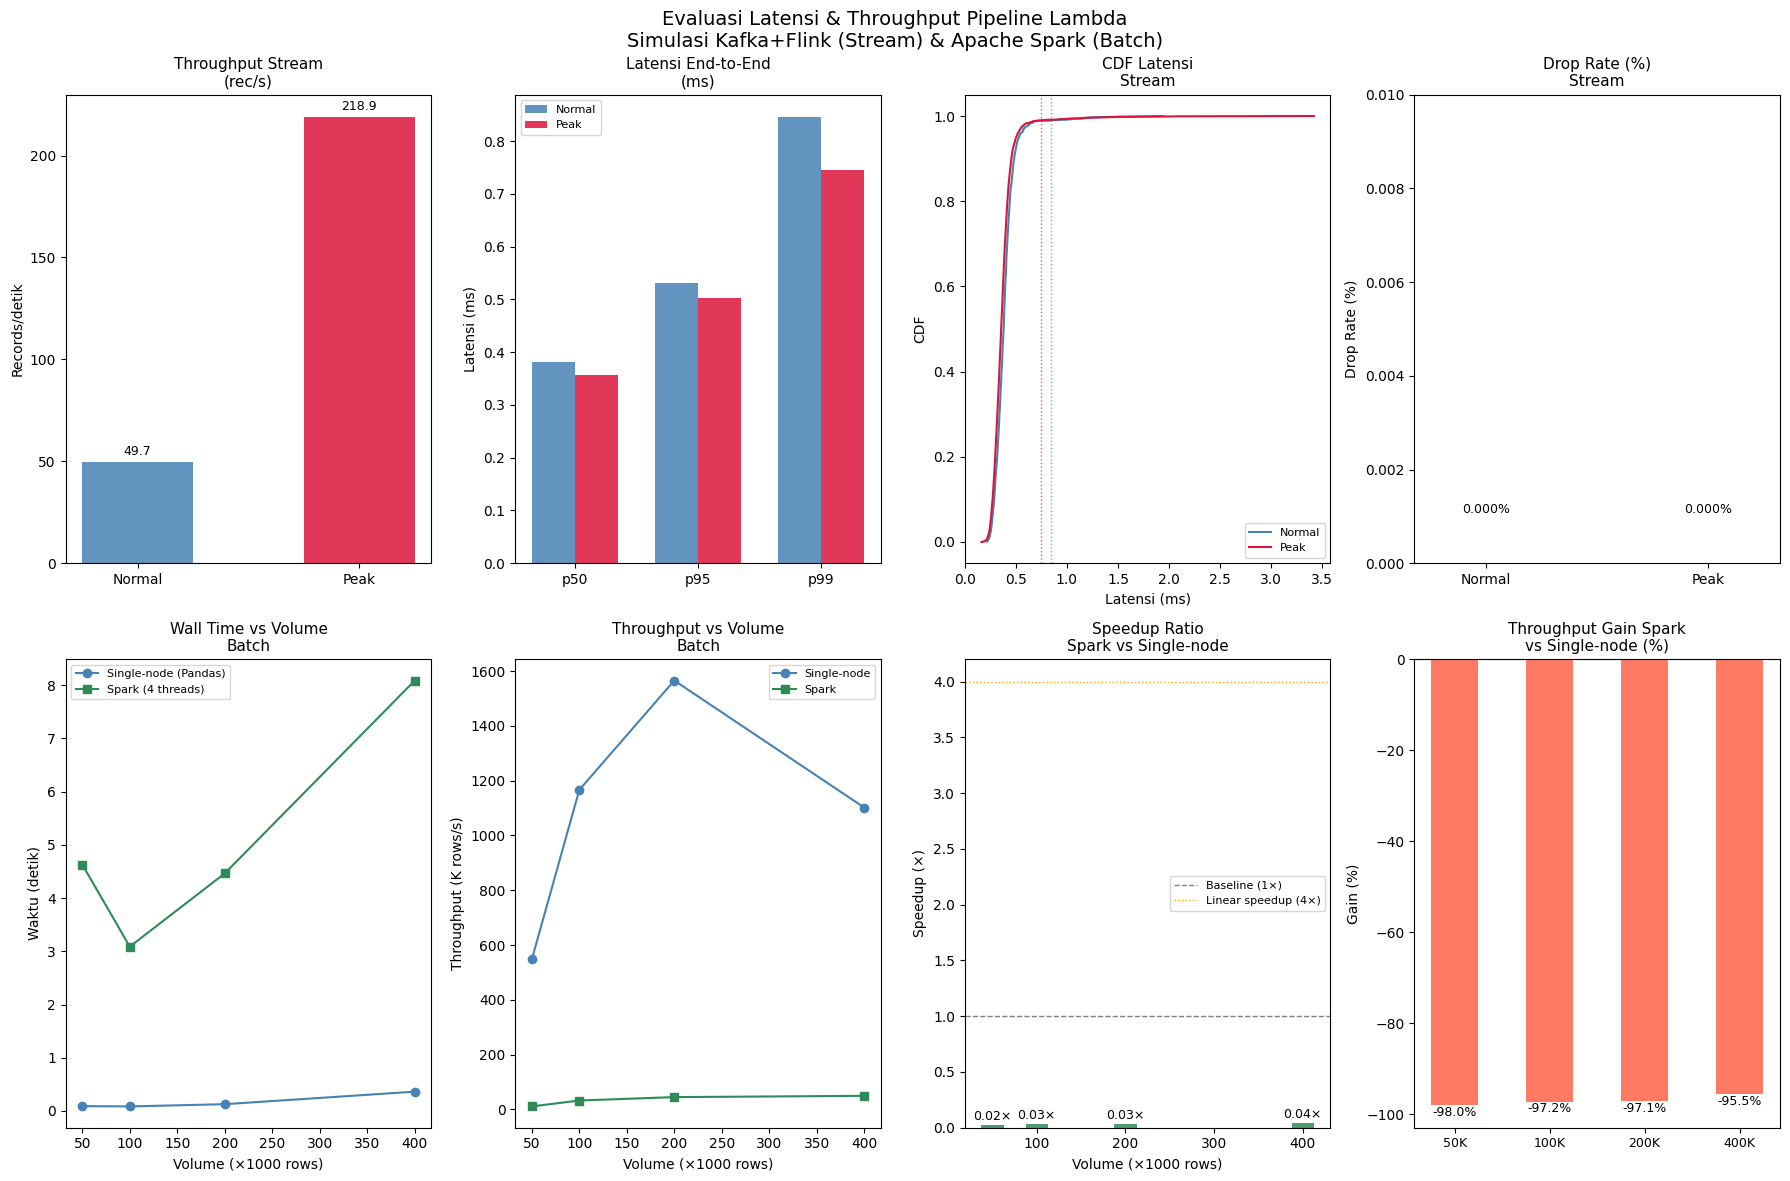

Plot disimpan: lambda_pipeline_evaluation.png


In [ ]:
# ============================================================
# CELL 8: VISUALISASI HASIL EKSPERIMEN
# ============================================================

fig = plt.figure(figsize=(18, 12))
fig.suptitle('Evaluasi Latensi & Throughput Pipeline Lambda\n'
             'Simulasi Kafka+Flink (Stream) & Apache Spark (Batch)',
             fontsize=14, y=0.98)

# ── Row 1: Stream ──────────────────────────────────────────

# Plot 1a: Throughput Normal vs Peak
ax1 = fig.add_subplot(2, 4, 1)
labels = [r['label'].split('(')[0].strip() for r in stream_results]
thpts  = [r['throughput_actual'] for r in stream_results]
colors_s = ['steelblue', 'crimson']
bars = ax1.bar(labels, thpts, color=colors_s, alpha=0.85, width=0.5)
ax1.set_title('Throughput Stream\n(rec/s)', fontsize=11)
ax1.set_ylabel('Records/detik')
for b, v in zip(bars, thpts):
    ax1.text(b.get_x()+b.get_width()/2, v+2, f'{v:.1f}',
             ha='center', va='bottom', fontsize=9)

# Plot 1b: Latency percentiles
ax2 = fig.add_subplot(2, 4, 2)
pct_labels = ['p50', 'p95', 'p99']
normal_lats = [result_normal['latency_p50_ms'],
               result_normal['latency_p95_ms'],
               result_normal['latency_p99_ms']]
peak_lats   = [result_peak['latency_p50_ms'],
               result_peak['latency_p95_ms'],
               result_peak['latency_p99_ms']]
x = np.arange(len(pct_labels))
w = 0.35
ax2.bar(x-w/2, normal_lats, w, label='Normal', color='steelblue', alpha=0.85)
ax2.bar(x+w/2, peak_lats,   w, label='Peak',   color='crimson',   alpha=0.85)
ax2.set_title('Latensi End-to-End\n(ms)', fontsize=11)
ax2.set_ylabel('Latensi (ms)')
ax2.set_xticks(x)
ax2.set_xticklabels(pct_labels)
ax2.legend(fontsize=8)

# Plot 1c: Latency distribution (CDF)
ax3 = fig.add_subplot(2, 4, 3)
for lats_arr, lbl, col in [
    (lats_normal, 'Normal', 'steelblue'),
    (lats_peak,   'Peak',   'crimson')
]:
    sorted_l = np.sort(lats_arr)
    cdf      = np.arange(1, len(sorted_l)+1) / len(sorted_l)
    ax3.plot(sorted_l, cdf, label=lbl, color=col, linewidth=1.5)
ax3.axvline(result_normal['latency_p99_ms'], color='steelblue',
            linestyle=':', alpha=0.7, linewidth=1)
ax3.axvline(result_peak['latency_p99_ms'],   color='crimson',
            linestyle=':', alpha=0.7, linewidth=1)
ax3.set_title('CDF Latensi\nStream', fontsize=11)
ax3.set_xlabel('Latensi (ms)')
ax3.set_ylabel('CDF')
ax3.legend(fontsize=8)
ax3.set_xlim(left=0)

# Plot 1d: Drop rate
ax4 = fig.add_subplot(2, 4, 4)
drop_rates = [r['drop_rate_pct'] for r in stream_results]
ax4.bar(labels, drop_rates, color=colors_s, alpha=0.85, width=0.5)
ax4.set_title('Drop Rate (%)\nStream', fontsize=11)
ax4.set_ylabel('Drop Rate (%)')
ax4.set_ylim(0, max(drop_rates) * 1.3 + 0.01)
for i, v in enumerate(drop_rates):
    ax4.text(i, v + 0.001, f'{v:.3f}%', ha='center', va='bottom', fontsize=9)

# ── Row 2: Batch ────────────────────────────────────────────

# Plot 2a: Wall time comparison
ax5 = fig.add_subplot(2, 4, 5)
ax5.plot(df_batch.index/1000, df_batch['single_time_s'],
         'o-', label='Single-node (Pandas)', color='steelblue', linewidth=1.5)
ax5.plot(df_batch.index/1000, df_batch['spark_time_s'],
         's-', label=f'Spark ({CFG["SPARK_THREADS"]} threads)', color='seagreen', linewidth=1.5)
ax5.set_title('Wall Time vs Volume\nBatch', fontsize=11)
ax5.set_xlabel('Volume (×1000 rows)')
ax5.set_ylabel('Waktu (detik)')
ax5.legend(fontsize=8)

# Plot 2b: Throughput comparison
ax6 = fig.add_subplot(2, 4, 6)
ax6.plot(df_batch.index/1000, df_batch['single_throughput']/1000,
         'o-', label='Single-node', color='steelblue', linewidth=1.5)
ax6.plot(df_batch.index/1000, df_batch['spark_throughput']/1000,
         's-', label='Spark', color='seagreen', linewidth=1.5)
ax6.set_title('Throughput vs Volume\nBatch', fontsize=11)
ax6.set_xlabel('Volume (×1000 rows)')
ax6.set_ylabel('Throughput (K rows/s)')
ax6.legend(fontsize=8)

# Plot 2c: Speedup ratio
ax7 = fig.add_subplot(2, 4, 7)
ax7.bar(df_batch.index/1000, df_batch['speedup_ratio'],
        color='seagreen', alpha=0.85, width=25)
ax7.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='Baseline (1×)')
ax7.axhline(CFG['SPARK_THREADS'], color='orange', linestyle=':',
            linewidth=1, label=f'Linear speedup ({CFG["SPARK_THREADS"]}×)')
ax7.set_title('Speedup Ratio\nSpark vs Single-node', fontsize=11)
ax7.set_xlabel('Volume (×1000 rows)')
ax7.set_ylabel('Speedup (×)')
ax7.legend(fontsize=8)
for i, (idx, row) in enumerate(df_batch.iterrows()):
    ax7.text(idx/1000, row['speedup_ratio']+0.02,
             f"{row['speedup_ratio']:.2f}×",
             ha='center', va='bottom', fontsize=9)

# Plot 2d: Throughput gain %
ax8 = fig.add_subplot(2, 4, 8)
gain_pct = ((df_batch['spark_throughput'] - df_batch['single_throughput'])
             / df_batch['single_throughput'] * 100)
bar_cols = ['seagreen' if v >= 0 else 'tomato' for v in gain_pct]
ax8.bar(range(len(gain_pct)), gain_pct, color=bar_cols, alpha=0.85, width=0.5)
ax8.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax8.set_title('Throughput Gain Spark\nvs Single-node (%)', fontsize=11)
ax8.set_xticks(range(len(df_batch)))
ax8.set_xticklabels([f'{n//1000}K' for n in df_batch.index], fontsize=9)
ax8.set_ylabel('Gain (%)')
for i, v in enumerate(gain_pct):
    ax8.text(i, v + 1 if v >= 0 else v - 3,
             f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('lambda_pipeline_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan: lambda_pipeline_evaluation.png")

In [ ]:
# ============================================================
# CELL 9: RINGKASAN AKHIR — SIAP UNTUK LAPORAN
# ============================================================

print("=" * 70)
print("  HASIL EKSPERIMEN: EVALUASI LATENSI & THROUGHPUT PIPELINE LAMBDA")
print("=" * 70)

print("""
──────────────────────────────────────────────────────────────
(a) JALUR STREAM — Simulasi Kafka + Flink
──────────────────────────────────────────────────────────────""")

stream_tbl = pd.DataFrame(stream_results).set_index('label')[[
    'rate_per_sec', 'total_sent', 'total_processed',
    'throughput_actual', 'latency_p50_ms',
    'latency_p95_ms', 'latency_p99_ms', 'drop_rate_pct'
]].rename(columns={
    'rate_per_sec'      : 'Rate (rec/s)',
    'total_sent'        : 'Sent',
    'total_processed'   : 'Processed',
    'throughput_actual' : 'Throughput (rec/s)',
    'latency_p50_ms'    : 'Lat p50 (ms)',
    'latency_p95_ms'    : 'Lat p95 (ms)',
    'latency_p99_ms'    : 'Lat p99 (ms)',
    'drop_rate_pct'     : 'Drop Rate (%)',
})
print(stream_tbl.round(3).to_string())

lat_deg = ((result_peak['latency_p99_ms'] -
            result_normal['latency_p99_ms']) /
            result_normal['latency_p99_ms'] * 100)
tpt_deg = ((result_normal['throughput_actual'] -
            result_peak['throughput_actual']) /
            result_normal['throughput_actual'] * 100)

print(f"""
  Degradasi latensi p99 saat peak (×{CFG['PEAK_MULTIPLIER']}): {lat_deg:+.1f}%
  Degradasi throughput saat peak                : {tpt_deg:+.1f}%
""")

print("""
──────────────────────────────────────────────────────────────
(b) JALUR BATCH — Apache Spark vs Single-node
──────────────────────────────────────────────────────────────""")
print(df_batch.rename(columns={
    'single_time_s'     : 'SingleNode Time (s)',
    'spark_time_s'      : 'Spark Time (s)',
    'single_throughput' : 'SingleNode Tput (rows/s)',
    'spark_throughput'  : 'Spark Tput (rows/s)',
    'speedup_ratio'     : 'Speedup Ratio (×)',
}).to_string())

avg_speedup = df_batch['speedup_ratio'].mean()
max_speedup = df_batch['speedup_ratio'].max()
print(f"""
  Rata-rata speedup ratio : {avg_speedup:.2f}×
  Speedup tertinggi       : {max_speedup:.2f}× (pada {df_batch['speedup_ratio'].idxmax():,} rows)
  Thread Spark            : {CFG['SPARK_THREADS']} (Colab gratis)
  Linear speedup teoritis : {CFG['SPARK_THREADS']}×
  Efisiensi parallelisme  : {avg_speedup/CFG['SPARK_THREADS']*100:.1f}%

──────────────────────────────────────────────────────────────
OUTPUT TERSIMPAN
  lambda_pipeline_evaluation.png
──────────────────────────────────────────────────────────────
""")
print("=" * 70)
print("  Eksperimen Pipeline Lambda selesai.")
print("=" * 70)

  HASIL EKSPERIMEN: EVALUASI LATENSI & THROUGHPUT PIPELINE LAMBDA

──────────────────────────────────────────────────────────────
(a) JALUR STREAM — Simulasi Kafka + Flink
──────────────────────────────────────────────────────────────
                        Rate (rec/s)  Sent  Processed  Throughput (rec/s)  Lat p50 (ms)  Lat p95 (ms)  Lat p99 (ms)  Drop Rate (%)
label                                                                                                                             
Normal (50 rec/s)                 50  1491       1491              49.669         0.381         0.530         0.846            0.0
Peak (225 rec/s, ×4.5)           225  6568       6568             218.909         0.357         0.503         0.746            0.0

  Degradasi latensi p99 saat peak (×4.5): -11.8%
  Degradasi throughput saat peak                : -340.7%


──────────────────────────────────────────────────────────────
(b) JALUR BATCH — Apache Spark vs Single-node
──────────────────────

Catatan penting untuk laporan:

Komponen | Status | Keterangan

Kafka | Disimulasikan | threading.Queue mereplikasi partisi & message ordering

Flink | Disimulasikan | Parallel consumer threads + tumbling window aggregation

Spark | Nyata | PySpark diinstall sungguhan, eksekusi nyata di Colab

Metrik | Diukur nyata | time.perf_counter() presisi tinggi, bukan dikira-kira